# Fake News Detection with NLP and Neural Networks

## Project Overview

This project applies Natural Language Processing (NLP) and machine learning techniques to classify news articles using their textual content.

The analysis explores text distributions and TF-IDF representations before comparing a traditional Multinomial Naive Bayes classifier with a Multi-Layer Perceptron (MLP) neural network for fake-news detection.

A multi-class classification experiment is also performed to predict the subject category of news articles.

## Objectives

- Explore patterns in fake and real news articles
- Prepare textual data for machine learning
- Transform text using Count Vectorization and TF-IDF
- Build a Multinomial Naive Bayes text classifier
- Build and evaluate a neural network classifier
- Compare traditional machine learning with a neural-network approach
- Explore multi-class news-subject classification

## 1. Data Loading and Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [2]:
df = pd.read_csv("news.csv", sep="\t", engine="python")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (44898, 5)


,title,text,subject,date,target
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [3]:
print("Missing Values Before Cleaning:")
display(df.isnull().sum())

df = df.dropna().copy()

print("\nMissing Values After Cleaning:")
display(df.isnull().sum())

Missing Values Before Cleaning:


title      0
text       0
subject    0
date       0
target     0
dtype: int64


Missing Values After Cleaning:


title      0
text       0
subject    0
date       0
target     0
dtype: int64

### News Subject Distribution

The distribution of article subjects is examined to understand which news categories are most represented in the dataset.

### Fake vs. Real News Distribution

The target distribution is examined to determine whether fake and real news articles are represented evenly in the dataset.

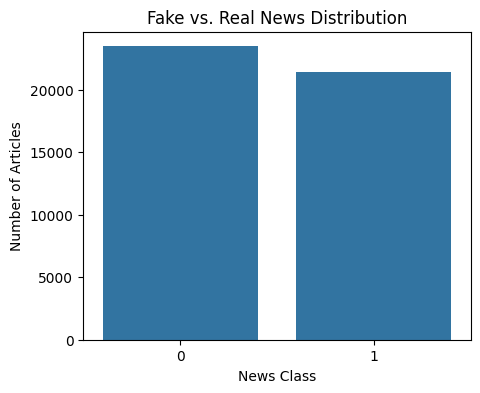

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="target")

plt.title("Fake vs. Real News Distribution")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")

plt.show()

### Observation

The fake and real news classes are relatively balanced, meaning neither class overwhelmingly dominates the dataset. This reduces concerns about severe class imbalance, although multiple evaluation metrics such as precision, recall, F1-score, and the confusion matrix will still be used when evaluating the models.

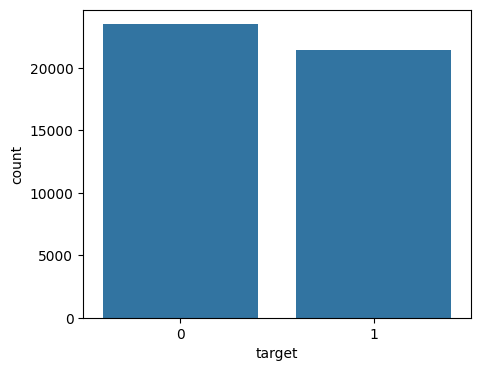

In [5]:
# vi.
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="target")
plt.show()

### Word Frequency Visualization

Word clouds provide an exploratory view of frequently occurring terms within fake and real news articles. They can help reveal differences in commonly used vocabulary between the two classes.

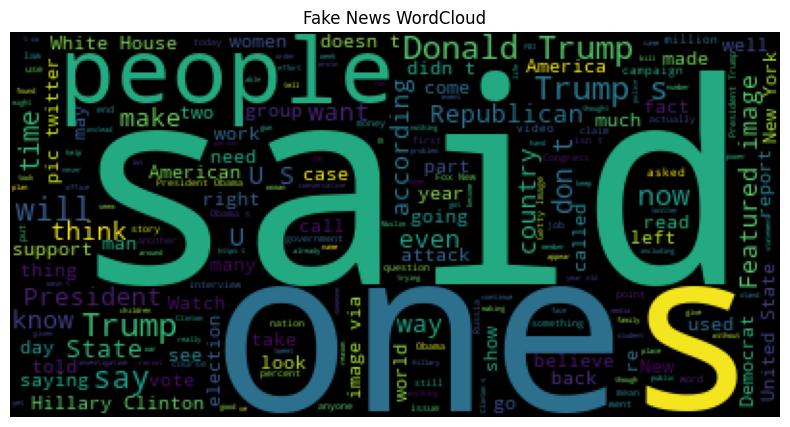

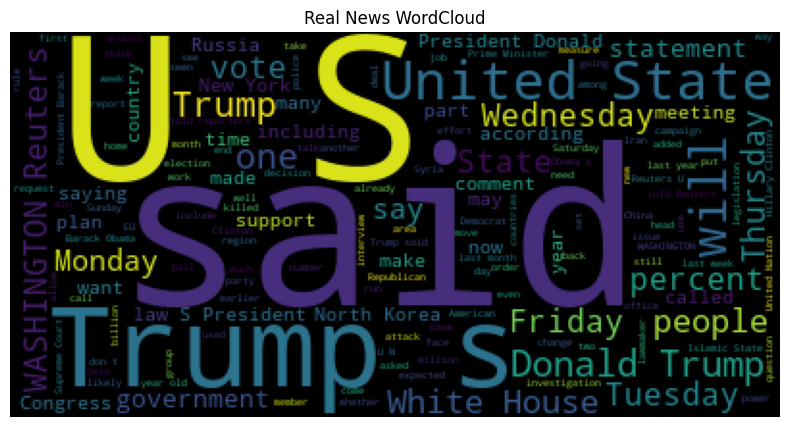

In [6]:
# vii.
fake_text = " ".join(df[df["target"] == 0]["text"])

plt.figure(figsize=(10,5))
plt.imshow(WordCloud().generate(fake_text))
plt.axis("off")
plt.title("Fake News WordCloud")
plt.show()

real_text = " ".join(df[df["target"] == 1]["text"])

plt.figure(figsize=(10,5))
plt.imshow(WordCloud().generate(real_text))
plt.axis("off")
plt.title("Real News WordCloud")
plt.show()

### Observation

The word clouds show differences in commonly occurring terms between fake and real news articles. Political figures and political terminology appear frequently in both classes, although the relative prominence of certain terms differs.

These visualizations are useful for exploratory analysis, but word frequency alone does not prove that a term is predictive of fake or real news. The classification models will use numerical text representations to determine whether broader vocabulary patterns can effectively distinguish between the two classes.

In [7]:
df["AllText"] = df["title"] + " " + df["text"]

In [8]:
# ix.
df_copy = df.copy()

In [9]:
df = df.drop(columns=["title", "text", "subject", "date"])

display(df.head())

,target,AllText
0,1,"As U.S. budget fight looms, Republicans flip t..."
1,1,U.S. military to accept transgender recruits o...
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...
3,1,FBI Russia probe helped by Australian diplomat...
4,1,Trump wants Postal Service to charge 'much mor...


### Article Length Analysis

The length of each combined article is calculated to examine whether fake and real news articles differ noticeably in the amount of textual content they contain.

In [10]:
# xi.
df["length"] = df["AllText"].apply(len)
df.head()

,target,AllText,length
0,1,"As U.S. budget fight looms, Republicans flip t...",4724
1,1,U.S. military to accept transgender recruits o...,4142
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,2850
3,1,FBI Russia probe helped by Australian diplomat...,2521
4,1,Trump wants Postal Service to charge 'much mor...,5274


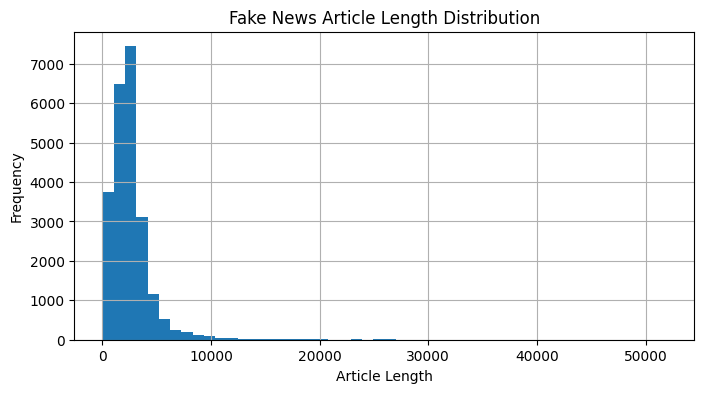

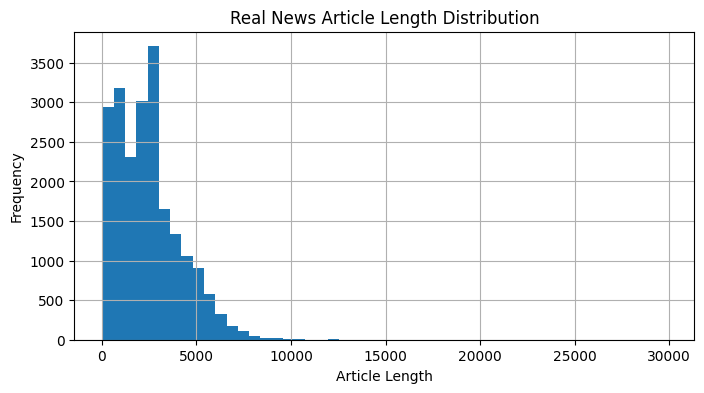

In [11]:
plt.figure(figsize=(8, 4))
df[df["target"] == 0]["length"].hist(bins=50)
plt.title("Fake News Article Length Distribution")
plt.xlabel("Article Length")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
df[df["target"] == 1]["length"].hist(bins=50)
plt.title("Real News Article Length Distribution")
plt.xlabel("Article Length")
plt.ylabel("Frequency")
plt.show()

### Observation

The article-length distributions show overlap between fake and real news articles. Article length may contain some useful information, but it is unlikely to be sufficient on its own for reliable classification.

This motivates the use of NLP techniques that analyze the words and vocabulary contained within the articles rather than relying only on document length.

## 2. Text Representation and Train/Test Split

Machine learning algorithms cannot directly process raw text, so the article content must first be converted into numerical features.

### Bag of Words

`CountVectorizer` converts the text into a document-term matrix based on word frequencies. Each feature represents a word from the vocabulary, and each value represents how often that word appears in an article.

### TF-IDF

TF-IDF stands for **Term Frequency–Inverse Document Frequency**. It assigns larger weights to words that are important within a particular article while reducing the influence of words that appear frequently across many articles.

In this project, `CountVectorizer` and `TfidfTransformer` are placed inside Scikit-learn pipelines so that text transformation is learned only from the training data.

In [12]:
from sklearn.model_selection import train_test_split

X = df["AllText"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 35918
Testing samples: 8980


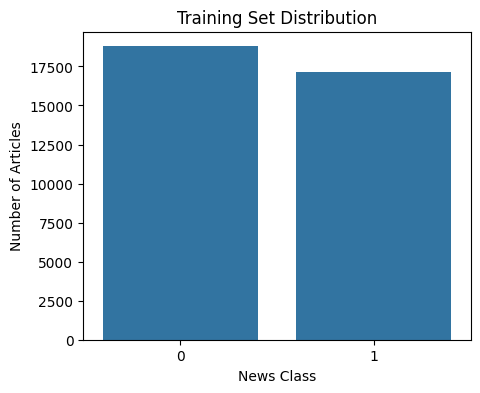

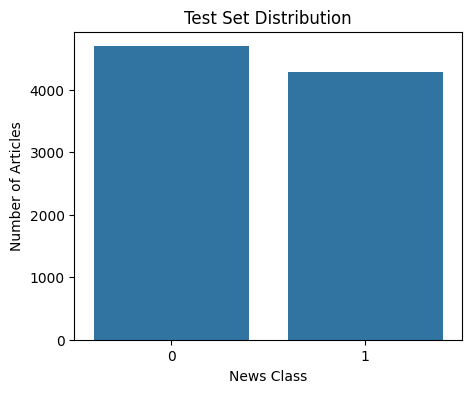

In [13]:
plt.figure(figsize=(5, 4))
sns.countplot(x=y_train)
plt.title("Training Set Distribution")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(x=y_test)
plt.title("Test Set Distribution")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")
plt.show()

### Observation

The stratified train/test split preserves the original class distribution in both subsets. This ensures that the training and testing sets contain comparable proportions of fake and real news articles.

## 3. Multinomial Naive Bayes Classification

Multinomial Naive Bayes provides a strong baseline for text-classification problems because it works efficiently with high-dimensional word-frequency features.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

nb_model = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("tfidf", TfidfTransformer()),
    ("classifier", MultinomialNB())
])

In [ ]:
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9388

Confusion Matrix:
[[4427  269]
 [ 281 4003]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4696
           1       0.94      0.93      0.94      4284

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



### Naive Bayes Performance

The Multinomial Naive Bayes classifier achieved approximately **93.9% accuracy** on the test set.

The model performed consistently across both classes, with precision, recall, and F1-scores of approximately 0.94 for both fake and real news articles. The confusion matrix shows 269 false positives and 281 false negatives, indicating relatively balanced performance across the two classes.

These results make Multinomial Naive Bayes a strong baseline for this text-classification problem. Its performance demonstrates that TF-IDF features contain substantial information for distinguishing fake and real news articles.

In [17]:
sample_news = [
    "Breaking: Scientists discover new breakthrough in AI technology that could change the world"
]

prediction = nb_model.predict(sample_news)[0]

label = "Real News" if prediction == 1 else "Fake News"

print("Predicted class:", prediction)
print("Prediction:", label)

Predicted class: 0
Prediction: Fake News


## 4. Neural Network Classification

After establishing Multinomial Naive Bayes as a baseline, a Multi-Layer Perceptron (MLP) neural network is evaluated on the same fake-vs-real news classification task.

Using the same training and testing data allows the neural network's performance to be compared directly with the Naive Bayes baseline.

In [18]:
from sklearn.neural_network import MLPClassifier

In [19]:
mlp_pipeline = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english", max_df=0.7)),
    ("tfidf", TfidfTransformer()),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=50,
        alpha=1e-4,
        solver="adam",
        early_stopping=True,
        random_state=42
    ))
])

In [20]:
mlp_pipeline.fit(X_train, y_train)

y_pred_mlp = mlp_pipeline.predict(X_test)

/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/

In [21]:
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

print(f"MLP Accuracy: {mlp_accuracy:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_mlp))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))

MLP Accuracy: 0.9906

Confusion Matrix:
[[4650   46]
 [  38 4246]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



### MLP Performance

The MLP neural network achieved approximately **99.1% accuracy** on the fake-vs-real news classification task.

Precision, recall, and F1-score were approximately 0.99 for both classes. The confusion matrix shows only 46 false positives and 38 false negatives out of 8,980 test articles.

The MLP substantially outperformed the Naive Bayes baseline on this dataset, suggesting that the neural network was able to learn more complex relationships among the TF-IDF features.

However, the unusually high performance should still be interpreted carefully. Characteristics of the dataset, such as recurring vocabulary, writing style, or source-specific patterns, may make the classes easier to distinguish than they would be in a real-world news environment.

In [22]:
sample_news = [
    "Breaking: Scientists discover new breakthrough in AI technology that could change the world"
]

prediction_mlp = mlp_pipeline.predict(sample_news)[0]

label_mlp = "Real News" if prediction_mlp == 1 else "Fake News"

print("Predicted class:", prediction_mlp)
print("Prediction:", label_mlp)

Predicted class: 0
Prediction: Fake News


/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Naive Bayes vs. MLP

The MLP neural network outperformed the Multinomial Naive Bayes baseline, achieving approximately **99.1% accuracy** compared with approximately **93.9%** for Naive Bayes.

Naive Bayes produced 550 total misclassifications, while the MLP produced only 84. Both models performed consistently across the fake and real news classes, but the MLP achieved substantially fewer false-positive and false-negative predictions.

Naive Bayes remains valuable because it is fast, simple, and effective for high-dimensional text data. The MLP requires more computation but can learn nonlinear relationships among text features, which may explain its stronger performance on this dataset.

Because both models were evaluated using the same stratified train/test split, their results can be compared directly.

## 5. Multi-Class News Subject Classification

In addition to fake-vs-real news detection, this section explores a multi-class classification problem: predicting the subject category of a news article from its textual content.

A separate MLP neural network is trained to classify articles into their corresponding news categories.

In [23]:
X_subject = df_copy["AllText"]
y_subject = df_copy["subject"]

print("Number of subject categories:", y_subject.nunique())
print("\nSubject distribution:")
display(y_subject.value_counts())

Number of subject categories: 8

Subject distribution:


subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

In [24]:
X_train_subject, X_test_subject, y_train_subject, y_test_subject = train_test_split(
    X_subject,
    y_subject,
    test_size=0.2,
    random_state=42,
    stratify=y_subject
)

print("Training samples:", len(X_train_subject))
print("Testing samples:", len(X_test_subject))

Training samples: 35918
Testing samples: 8980


In [25]:
subject_model = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("tfidf", TfidfTransformer()),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=50,
        random_state=42
    ))
])

In [26]:
subject_model.fit(X_train_subject, y_train_subject)

y_pred_subject = subject_model.predict(X_test_subject)

/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [27]:
subject_accuracy = accuracy_score(y_test_subject, y_pred_subject)

print(f"Subject Classification Accuracy: {subject_accuracy:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_subject, y_pred_subject))

print("\nClassification Report:")
print(classification_report(y_test_subject, y_pred_subject))

Subject Classification Accuracy: 0.7106

Confusion Matrix:
[[  15    0    2    0   40  249    7    1]
 [   0   19    0  136    0    0    1    0]
 [   0    0 1754    0   10   40    6    0]
 [   0  145    0   11    0    0    1    0]
 [  40    0    7    0   50  788    4    3]
 [ 179    0   10    0  567  597   15    0]
 [   4    0    7    0   20   31 2082  110]
 [   1    0    1    0   14   11  149 1853]]

Classification Report:
                 precision    recall  f1-score   support

Government News       0.06      0.05      0.05       314
    Middle-east       0.12      0.12      0.12       156
           News       0.98      0.97      0.98      1810
        US_News       0.07      0.07      0.07       157
      left-news       0.07      0.06      0.06       892
       politics       0.35      0.44      0.39      1368
   politicsNews       0.92      0.92      0.92      2254
      worldnews       0.94      0.91      0.93      2029

       accuracy                           0.71      8980


### Subject Classification Performance

The multi-class MLP achieved approximately **71.1% accuracy** when predicting one of eight news subject categories from article titles and text.

Performance varied substantially across categories. The model performed particularly well on `News`, `politicsNews`, and `worldnews`, achieving F1-scores of approximately 0.98, 0.92, and 0.93 respectively.

Performance was much weaker for `Government News`, `Middle-east`, `US_News`, and `left-news`. These categories contain overlapping political vocabulary and also have fewer training examples, making them more difficult for the model to distinguish.

The weighted F1-score was approximately 0.71, while the macro-average F1-score was only 0.44. This difference indicates that the model performs much better on the larger subject categories than on several of the smaller categories.

Overall, the experiment demonstrates that multi-class subject prediction is substantially more challenging than binary fake-vs-real classification.

## 6. Model Comparison and Conclusion

In [ ]:
from sklearn.metrics import f1_score

model_comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "MLP - Fake vs. Real",
        "MLP - Subject Classification"
    ],
    "Accuracy": [
        nb_accuracy,
        mlp_accuracy,
        subject_accuracy
    ],
    "Weighted F1 Score": [
        f1_score(y_test, y_pred_nb, average="weighted"),
        f1_score(y_test, y_pred_mlp, average="weighted"),
        f1_score(y_test_subject, y_pred_subject, average="weighted")
    ]
})

model_comparison.round(3)

### Conclusion

This project explored Natural Language Processing techniques for both binary and multi-class news classification.

For fake-vs-real news detection, Multinomial Naive Bayes provided a strong baseline with approximately **93.9% accuracy**. The MLP neural network achieved the strongest binary-classification performance with approximately **99.1% accuracy**, demonstrating that a neural network can effectively learn complex relationships from TF-IDF text features.

The multi-class subject-classification task was more challenging. The subject MLP achieved approximately **71.1% accuracy**, with considerably stronger performance on larger categories such as `News`, `politicsNews`, and `worldnews` than on several smaller categories. This highlights the additional difficulty of distinguishing between multiple news categories with overlapping vocabulary.

Overall, the project demonstrates a complete NLP workflow including exploratory data analysis, text preprocessing, TF-IDF feature extraction, probabilistic classification, neural-network classification, and model evaluation.

The results also demonstrate the importance of preventing target leakage and evaluating models beyond accuracy alone. Although the binary MLP achieved very high performance on this dataset, these results should not automatically be interpreted as equivalent real-world performance. Future work could evaluate the models on external news sources, investigate duplicate or source-specific articles, and explore more advanced NLP architectures.

### Key Takeaways

- TF-IDF provides an effective numerical representation of news text for machine learning.
- Multinomial Naive Bayes provides a fast and effective baseline for text classification.
- The MLP neural network substantially improved fake-vs-real classification performance on this dataset.
- Multi-class subject classification was considerably more difficult than binary classification.
- Class-specific metrics such as precision, recall, and F1-score provide important information beyond overall accuracy.
- Preventing target leakage is essential for obtaining meaningful model-evaluation results.